# Trabajo Práctico - Aprendizaje Automático

## SetUp




In [42]:
import math

from six import StringIO 
from IPython.display import Image, display
import pydotplus

import numpy as np
import pandas as pd
import pingouin as pg
from scipy.stats import shapiro

import matplotlib.pyplot as plt
import seaborn as sns

import sklearn

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif

from sklearn.model_selection import (cross_validate, StratifiedKFold, ParameterGrid, RandomizedSearchCV)

from sklearn.calibration import CalibratedClassifierCV
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (accuracy_score, average_precision_score, classification_report, confusion_matrix, recall_score, roc_auc_score, roc_curve)

In [43]:
# Seteamos la semilla para que los resultados sean reproducibles
SEED = 2026
np.random.seed(SEED)

# Definimos el K-Fold estratificado para usar en la validación cruzada de los modelos
stratifiedKFold = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

### Definición de Funciones

In [44]:
df_completo = pd.read_csv('data.csv')

## Separación de Datos de Desarrollo y Control

## Ejercico 1.1 
Vamos a mantener proporciones de las clases en los conjuntos de Desarrollo y Control.

In [45]:
# Función para separar el dataset en train y test, manteniendo la proporción de clases
# p = proporción de datos para control
def train_test_split(df, p=0.2):
    # Separo las filas por clase
    filas_y1 = df[df['target'] == 1] #las filas con y = 1
    filas_y0 = df[df['target'] == 0] # con y = 0
    
    prop_buen_pronostico = filas_y1.shape[0]/df.shape[0]
    print("Proporción de clase positiva: ", prop_buen_pronostico) # La proporción de los datos dados es del 0.282

    cant_buen_pronostico = int(df.shape[0] * p *    prop_buen_pronostico)
    cant_mal_pronostico = int(df.shape[0] * p * (1-prop_buen_pronostico))

    test = pd.DataFrame(columns=filas_y1.columns).astype(filas_y1.dtypes) #hago db con las columnas
    test = pd.concat([test, filas_y1.sample(n=cant_buen_pronostico, random_state=SEED)], ignore_index=False) #sampleo 
    test = pd.concat([test, filas_y0.sample(n=cant_mal_pronostico, random_state=SEED)], ignore_index=False)

    train = df.drop(test.index, axis=0)  # REVISAR

    return train.drop(columns=['target']), train['target'], test.drop(columns=['target']), test['target']

In [46]:
# Definimos el dataset que usaremos para desarrollar el modelo y el dataset de control que usaremos para evaluar el modelo.
X_train, y_train, X_control, y_control = train_test_split(df_completo)

df_control = pd.concat([X_control, y_control], axis=1)
df = pd.concat([X_train, y_train], axis=1)

Proporción de clase positiva:  0.282


## Ejercicio 1.2
Inicialmente tuvimos estas consideraciones:
- Mantener las proporciones de las etiquetas en desarrollo y control, con el objetivo de entrenar un modelo con las mismas proporciones que se encontraría en la realidad (suponiendo que las proporciones actuales son representativas de la realidad)
- Agrupar por paciente las instancias, las que pertenecen al mismo paciente que no puedan estar en el conjunto de control y desarrollo a la vez.
- Agrupar temporalmente, para no entrenar a los modelos con instancias del futuro y que sean evaluados con datos del pasado.

Luego de inspeccionar los datos solo llevamos a cabo la primera, el dataset no tiene la información necesaria para hacer el agrupamiento por paciente y temporal.


## Ejercicio 2

In [47]:
# Función para entrenar un árbol de decisión con una semilla fija
def train_tree(X_tr: np.ndarray, y_tr: np.ndarray, tree_params={}) -> DecisionTreeClassifier:
    arbol = DecisionTreeClassifier(**tree_params, random_state=SEED)
    arbol.fit(X_tr, y_tr)

    return arbol

def dibujar_arbol(clf, c_name=['0','1'], f_name=df.drop(columns=['target']).columns):
    # modo de uso: dibujar_arbol(arbol, nombres_de_clases, nombres_de_features)
    if(c_name is None or f_name is None):
        return "Debe especificar los nombres de las clases y de las features"

    dot_data = StringIO()
    sklearn.tree.export_graphviz(clf, out_file = dot_data,
                    filled = True,
                    class_names = c_name,
                    feature_names = f_name,
                    special_characters = True)

    graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
    display(Image(graph.create_png()))

In [48]:
def stratifiedKFoldCV(algoritmo, X_train, y_train, cv):
    resultados_folds = []

    y_global_true = np.empty(len(y_train))
    y_global_pred = np.empty(len(y_train))
    y_global_proba = np.empty(len(y_train)) # El nombre proba es por aucroc devuelve la probabilidad de pertenecer a la clase.

    for fold_idx, (train_index, val_index) in enumerate(cv.split(X_train, y_train)):

        kf_X_train, kf_X_test = X_train.iloc[train_index], X_train.iloc[val_index]
        kf_y_train, kf_y_test = y_train.iloc[train_index], y_train.iloc[val_index]

        algoritmo.fit(kf_X_train, kf_y_train)
        print(algoritmo.classes_)
        y_pred_train = algoritmo.predict(kf_X_train)
        y_pred_test = algoritmo.predict(kf_X_test)
        #y_pred_control = modelo.predict(X_control)
        #y_pred_proba_control = algoritmo.predict_proba(X_control)[:,1]
        #acc_control = accuracy_score(y_control,y_pred_control)
        #auc_prc_control = average_precision_score(y_control, y_pred_proba_control)
        #auc_roc_control = roc_auc_score(y_control, y_pred_proba_control)
        
        # Probabilidad de pertenecer a la clase positiva, buen pronóstico (la mayoritaria)
        y_pred_proba_train = algoritmo.predict_proba(kf_X_train)[:, 1]
        y_pred_proba_test = algoritmo.predict_proba(kf_X_test)[:, 1]

        y_global_true[val_index] = kf_y_test
        y_global_pred[val_index] = y_pred_test
        y_global_proba[val_index] = y_pred_proba_test

        resultados_folds.append({
            'Permutación': str(fold_idx),
            'Accuracy (train)': accuracy_score(kf_y_train, y_pred_train),
            'Accuracy (validation)': accuracy_score(kf_y_test, y_pred_test),
            'AUC-PRC (train)': average_precision_score(kf_y_train, y_pred_proba_train),
            'AUC-PRC (validation)': average_precision_score(kf_y_test, y_pred_proba_test),
            'AUC-ROC (train)': roc_auc_score(kf_y_train, y_pred_proba_train),
            'AUC-ROC (validation)': roc_auc_score(kf_y_test, y_pred_proba_test)
        })

    df_tabla = pd.DataFrame(resultados_folds)

    promedios = df_tabla.drop(columns=['Permutación']).mean()
    df_tabla.loc[len(df_tabla)] = ['Promedios'] + list(promedios)

    df_tabla.loc[len(df_tabla)] = [
        'Global',
        '(NO)',
        accuracy_score(y_global_true, y_global_pred),
        '(NO)',
        average_precision_score(y_global_true, y_global_proba),
        '(NO)',
        roc_auc_score(y_global_true, y_global_proba)
    ]

    return df_tabla

### Ejercicio 2.1

In [49]:
X_train, y_train, X_test, y_test = train_test_split(df)

tree_1 = train_tree(X_train, y_train, tree_params={'max_depth': 3})

print("Score sobre el dataset de entrenamiento: ", tree_1.score(X_train, y_train))
print("Score sobre el dataset de prueba: ", tree_1.score(X_test, y_test))


Proporción de clase positiva:  0.2817955112219451
Score sobre el dataset de entrenamiento:  0.8478260869565217
Score sobre el dataset de prueba:  0.6455696202531646


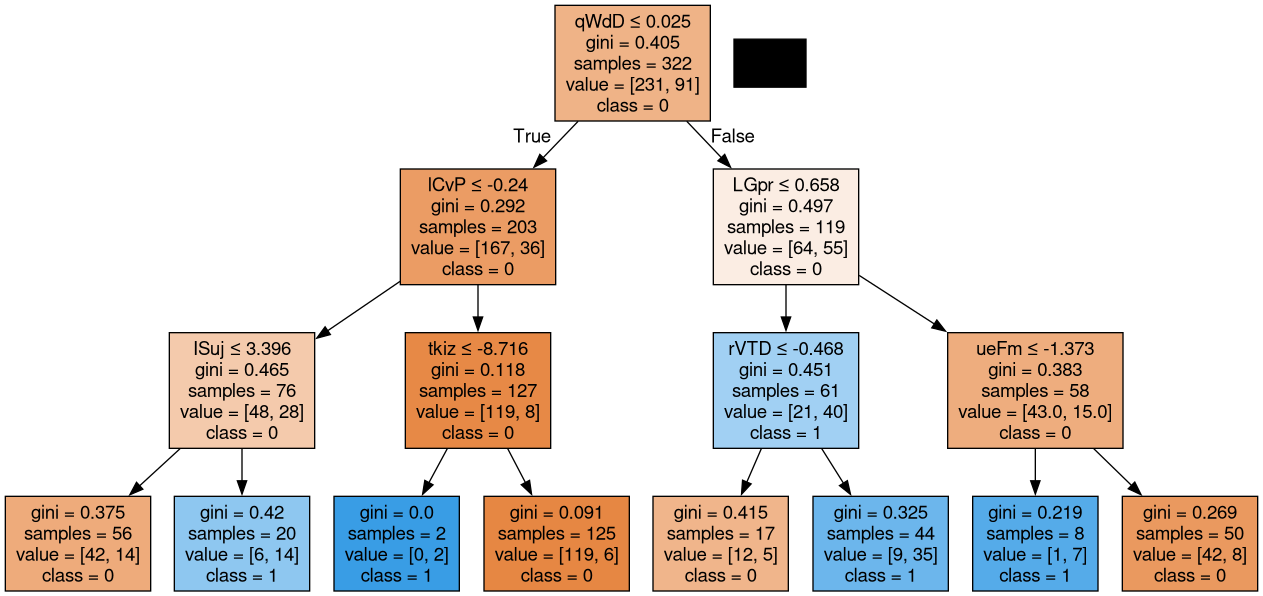

In [50]:
dibujar_arbol(tree_1)

### Ejercicio 2.2

In [51]:
tree = DecisionTreeClassifier(max_depth=3, random_state=SEED)
X_train, y_train = df.drop(columns=['target']), df['target']

stratifiedKFoldCV(tree, X_train, y_train, stratifiedKFold)

[0 1]
[0 1]
[0 1]
[0 1]
[0 1]


,Permutación,Accuracy (train),Accuracy (validation),AUC-PRC (train),AUC-PRC (validation),AUC-ROC (train),AUC-ROC (validation)
0,0,0.825,0.728395,0.688876,0.457783,0.843647,0.720765
1,1,0.841121,0.612500,0.692027,0.353266,0.864142,0.618730
2,2,0.813084,0.687500,0.658068,0.420417,0.846417,0.737069
3,3,0.82866,0.650000,0.70596,0.412458,0.870659,0.670862
4,4,0.831776,0.612500,0.682425,0.372447,0.849254,0.673150
5,Promedios,0.827928,0.658179,0.685471,0.403274,0.854824,0.684115
6,Global,(NO),0.658354,(NO),0.394941,(NO),0.682922


### Ejercicio 2.3

In [52]:
def grid_search_tree(X_train, y_train, param_grid={'max_depth': [3,5,None], 'criterion': ['gini', 'entropy']}, metric='accuracy'):
    grid = ParameterGrid(param_grid)
    res = []
    
    for params in grid:
        current_tree = DecisionTreeClassifier(**params, random_state=SEED)
        
        cv_results = cross_validate(
            current_tree, 
            X_train, 
            y_train, 
            cv=stratifiedKFold, 
            scoring=metric, 
            return_train_score=True 
        )
        
        fila = {}
        for param_name, param_value in params.items():
            if param_name == 'max_depth' and param_value is None:
                fila[param_name] = 'Infinito'
            else:
                fila[param_name] = param_value
                
        fila[f'{metric} (training)'] = cv_results['train_score'].mean()
        fila[f'{metric} (validación)'] = cv_results['test_score'].mean()
        
        res.append(fila)

    return pd.DataFrame(res)

In [53]:
X_train, y_train = df.drop(columns=['target']), df['target']
res = grid_search_tree(X_train, y_train)

In [54]:
res

,criterion,max_depth,accuracy (training),accuracy (validación)
0,gini,3,0.827928,0.658179
1,gini,5,0.933289,0.683179
2,gini,Infinito,1.000000,0.685710
3,entropy,3,0.803621,0.678241
4,entropy,5,0.885923,0.655741
5,entropy,Infinito,1.000000,0.658148


### Ejercicio 2.4


Clase 0 = mal pronóstico = clase mayoritaria → NEGATIVA

Clase 1 = buen pronósitco = clase minoritaria → POSITIVA

Suponemos que queremos encontrar una forma de prevenir el cáncer (o algo así), por eso nos interesan las instancias que tiene un buen pronóstico, ya que son las que poseen cierta predisposición al cáncer pero no lo terminan de desarrollar. Queremos encontrar qué genes evitan el desarrollo.

La clase positiva es díficil de clasificar como porque hay pocas instancias con las que entrenar el modelo.
Esto se ve reflejado en valores muy bajos de AUC-PRC. Ya que el modelo solo mejora recall sacrificando la precision.

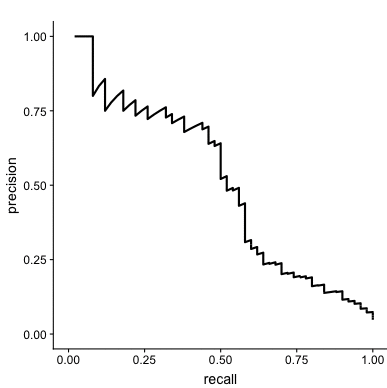

Esto quiere decir que el modelo no aprende a identificar a la clase positiva, ya que solo son clasificados como tal con un umbral bajo (por eso empeora tanto la precision).
El modelo clasifica a los positivos con una seguridad baja.
como hay pocos datos de la clase positiva el modelo no aprende a identificar a los positivos y predice a la instanacia con probabilidad similar como negativa o positiva 

Queremos un modelo que encuentre el cáncer ¿?
Es preferible recall

Podemos concluir que conviene usar un árbol de altura 5 contra cualquier árbol de altura mayor.
Se obtiene una performance similar y un modelo mucho más simple.
Aún así el ningún árbol tiene una performance mejor que un modelo dummy que predice siempre la clase mayoritaria.
Gini tiene mejor performance para arboles grandes.

## Ejercicio 3

In [55]:
# Función para generar una tabla de resultados a partir de un objeto RandomizedSearchCV entrenado
def generar_tabla_resultados(busqueda_entrenada):
    df_resultados = pd.DataFrame(busqueda_entrenada.cv_results_)
    
    columnas_params = [col for col in df_resultados.columns if col.startswith('param_')]
    columnas_metricas = [
        'rank_test_score',
        'mean_test_score',
        'std_test_score'
    ]

    columnas_totales = columnas_metricas + columnas_params
    tabla_limpia = df_resultados[columnas_totales].sort_values(by='rank_test_score')
    
    mapeo_nombres = {col: col.replace('param_', '') for col in columnas_params}
    tabla_limpia = tabla_limpia.rename(columns=mapeo_nombres)

    return tabla_limpia

### Ejercicio 3.1

#### Árboles de Decisión

In [56]:
X_train, y_train = df.drop(columns=['target']), df['target']

random_search_tree = RandomizedSearchCV(
    estimator=DecisionTreeClassifier(random_state=SEED),
    param_distributions={
        'max_depth': [3, 5, 6, 7, None],
        'criterion': ['gini', 'entropy'],
        'max_features' : [None, 'sqrt', 'log2'],
        'min_samples_split' : [2, 3, 4, 5],
    }, # restringe el espacio de búsqueda a estos valores
    n_iter=10, # combinaciones aleatorias a probar
    scoring='roc_auc', # métrica a optimizar
    cv=stratifiedKFold,
    random_state=SEED,
    return_train_score=True,
    n_jobs=-1 # esto permite usar todos los cores de CPU
)

random_search_tree.fit(X_train, y_train)

generar_tabla_resultados(random_search_tree)

,rank_test_score,mean_test_score,std_test_score,min_samples_split,max_features,max_depth,criterion
8,1,0.630715,0.040140,4,log2,3,gini
3,2,0.623729,0.091189,3,None,3,entropy
4,3,0.607787,0.057845,4,log2,7,gini
2,4,0.597850,0.034819,2,sqrt,5,gini
9,5,0.592025,0.056538,4,None,5,entropy
7,6,0.577990,0.042343,3,sqrt,7,gini
6,7,0.575821,0.071956,4,sqrt,6,entropy
1,8,0.568766,0.051212,4,sqrt,7,gini
0,9,0.562490,0.058635,3,sqrt,None,gini
5,10,0.514348,0.019328,2,log2,None,entropy


In [57]:
stratifiedKFoldCV(random_search_tree.best_estimator_, X_train, y_train, stratifiedKFold)

[0 1]
[0 1]
[0 1]
[0 1]
[0 1]


,Permutación,Accuracy (train),Accuracy (validation),AUC-PRC (train),AUC-PRC (validation),AUC-ROC (train),AUC-ROC (validation)
0,0,0.75,0.604938,0.537896,0.383249,0.782367,0.681034
1,1,0.778816,0.625000,0.567746,0.336708,0.774486,0.601097
2,2,0.760125,0.700000,0.548841,0.318002,0.789202,0.584639
3,3,0.778816,0.650000,0.60576,0.373334,0.806061,0.610221
4,4,0.794393,0.700000,0.571626,0.446276,0.786219,0.676583
5,Promedios,0.77243,0.655988,0.566374,0.371514,0.787667,0.630715
6,Global,(NO),0.655860,(NO),0.353091,(NO),0.627612


#### KNN

In [58]:
X_train, y_train = df.drop(columns=['target']), df['target']

random_search_KNN = RandomizedSearchCV(
    estimator=KNeighborsClassifier(),
    param_distributions={
        'n_neighbors': range(1,20),
        'weights': ["uniform","distance"],
        'metric':["cityblock","cosine","euclidean"]
    }, 
    n_iter=10, 
    scoring='roc_auc',
    cv=stratifiedKFold,
    random_state=SEED,
    return_train_score=True,
    
)

random_search_KNN.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'metric': ['cityblock', 'cosine', ...], 'n_neighbors': range(1, 20), 'weights': ['uniform', 'distance']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",2026
,"return_train_score return_train_score: bool, default=FalseIf ``False``, the ``cv_results_`` attribute will not include trainingscores.Computing training scores is used to get insights on how differentparameter settings impact the overfitting/underfitting trade-off.However computing the scores on the training set can be computationallyexpensive and is not strictly required to select the parameters thatyield the best generalization performance... versionadded:: 0.19.. versionchanged:: 0.21 Default value was changed from ``True`` to ``False``",True
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for 

In [59]:
generar_tabla_resultados(random_search_KNN)

,rank_test_score,mean_test_score,std_test_score,weights,n_neighbors,metric
9,1,0.833444,0.032510,distance,4,cosine
5,2,0.832521,0.057691,uniform,19,cosine
6,3,0.826773,0.035292,uniform,5,cosine
7,4,0.821894,0.051953,uniform,10,cityblock
2,5,0.809772,0.063806,uniform,12,euclidean
1,6,0.806826,0.064954,uniform,6,cityblock
8,7,0.765895,0.064830,uniform,7,euclidean
0,8,0.743684,0.049291,distance,3,euclidean
4,9,0.725795,0.050272,uniform,3,euclidean
3,10,0.695801,0.038366,distance,1,cosine


#### SVM

In [ ]:
# Espacio de búsqueda de hiperparámetros
# Probar parámtero Gamma luego
# Kernel Exponencial Cuadrático = rbf (similar al qué está en el libro)
# Kernel sigmoid: ¿En qué casos es más útil?
# Revisar valores de C, la escala logaritmica es para explorar un rango grande de valores
# ya que no es lineal la relación entre los valores de C y el desempeño del modelo
def mejor_SVC_dado_df(X_train, y_train):
    param_dist = [
        {
            'svc__estimator__kernel': ['rbf'],
            'svc__estimator__C': np.logspace(-3, 3, 7),
            'svc__estimator__gamma': list(np.logspace(-4, 1, 6)) + ['scale', 'auto'],
        },
        {
            'svc__estimator__kernel': ['poly'],
            'svc__estimator__C': np.logspace(-3, 3, 7),
            'svc__estimator__gamma': list(np.logspace(-4, 1, 6)) + ['scale', 'auto'],
            'svc__estimator__degree': [2],
            'svc__estimator__coef0': [0.0, 0.1, 0.5],
        },
        {
            'svc__estimator__kernel': ['linear'],
            'svc__estimator__C': np.logspace(-3, 3, 7),
        },
    ]

    pipe = Pipeline([
        # Escalar para evitar problema de magnitudes diferentes entre features
        ('scaler', StandardScaler()),
        ('svc', CalibratedClassifierCV(SVC(), ensemble=False, cv=5))
    ])

    random_search_svc = RandomizedSearchCV(
        pipe,
        param_distributions=param_dist,
        n_iter=20,
        scoring='roc_auc',
        cv=stratifiedKFold,
        random_state=SEED,
        n_jobs=-1
    )
    
    random_search_svc.fit(X_train, y_train)
    return random_search_svc

In [61]:
random_search_svc = mejor_SVC_dado_df(X_train, y_train)
random_search_svc.best_params_

{'svc__estimator__kernel': 'poly',
 'svc__estimator__gamma': np.float64(0.01),
 'svc__estimator__degree': 2,
 'svc__estimator__coef0': 0.1,
 'svc__estimator__C': np.float64(1.0)}

In [62]:
generar_tabla_resultados(random_search_svc)

,rank_test_score,mean_test_score,std_test_score,svc__estimator__kernel,svc__estimator__gamma,svc__estimator__degree,svc__estimator__coef0,svc__estimator__C
17,1,0.811150,0.041359,poly,0.01,2.0,0.1,1.000
12,2,0.767710,0.070452,rbf,0.01,NaN,NaN,10.000
19,2,0.767710,0.070452,rbf,0.01,NaN,NaN,100.000
15,4,0.764167,0.054479,poly,0.01,2.0,0.5,1000.000
13,5,0.750627,0.047668,poly,0.0001,2.0,0.0,100.000
3,6,0.749677,0.063291,poly,1.0,2.0,0.1,10.000
10,7,0.749520,0.063129,poly,10.0,2.0,0.5,1.000
4,7,0.749520,0.063129,poly,10.0,2.0,0.5,10.000
16,7,0.749520,0.063129,poly,10.0,2.0,0.5,0.100
5,10,0.749419,0.049105,poly,scale,2.0,0.0,0.100


In [63]:
stratifiedKFoldCV(random_search_svc.best_estimator_, X_train, y_train, stratifiedKFold)

[0 1]
[0 1]
[0 1]
[0 1]
[0 1]


,Permutación,Accuracy (train),Accuracy (validation),AUC-PRC (train),AUC-PRC (validation),AUC-ROC (train),AUC-ROC (validation)
0,0,1.0,0.703704,1.0,0.578191,1.0,0.775112
1,1,1.0,0.787500,1.0,0.736700,1.0,0.870690
2,2,1.0,0.750000,1.0,0.589028,1.0,0.812696
3,3,1.0,0.787500,1.0,0.591506,1.0,0.757437
4,4,1.0,0.875000,1.0,0.786878,1.0,0.839817
5,Promedios,1.0,0.780741,1.0,0.656461,1.0,0.811150
6,Global,(NO),0.780549,(NO),0.623231,(NO),0.811947


### Ejercicio 3.2

#### LDA

In [64]:
X_train, y_train = df.drop(columns=['target']), df['target']
nb_model = LinearDiscriminantAnalysis()

resultados_lda = cross_validate(
    nb_model,
    X_train,
    y_train,
    cv=stratifiedKFold,
    scoring='roc_auc'
)

aucroc_promedio_nb = resultados_lda['test_score'].mean()
print(f"AUCROC promedio de LDA: {aucroc_promedio_nb:.4f}")

AUCROC promedio de LDA: 0.6265


#### Naive Bayes

In [65]:
X_train, y_train = df.drop(columns=['target']), df['target']
nb_model = GaussianNB()

resultados_nb = cross_validate(
    nb_model, 
    X_train,
    y_train, 
    cv=stratifiedKFold, 
    scoring='roc_auc'
)

aucroc_promedio_nb = resultados_nb['test_score'].mean()
print(f"AUCROC promedio de Naïve Bayes (Default): {aucroc_promedio_nb:.4f}")

AUCROC promedio de Naïve Bayes (Default): 0.7291


### Ejercicio 3.3 - Mejor Modelo

El mejor modelo es SVC, con los siguientes hiperparámetros:
'svc__estimator__kernel': 'poly'
'svc__estimator__gamma': np.float64(0.01)
'svc__estimator__degree': 2
'svc__estimator__coef0': 0.1
'svc__estimator__C': np.float64(1.0)

Creemos que tuvo el mejor desempeño porque la frontera de decisión no es lineal y no

## Sesgo de SVC
Los datos son separables linealmente en algún espacio de características (posiblemente de alta dimensión) con un margen máximo.

La mejor frontera de decisión es la que maximiza el margen entre clases, lo que reduce el riesgo de sobreajuste.

Se permite cierto error de clasificación mediante el parámetro de regularización 
C
C (soft margin).

Para datos no lineales, se usa un kernel que mapea implícitamente a un espacio de mayor dimensión donde la separación lineal es posible.

Este sesgo inductivo favorece soluciones suaves y robustas, pero puede ser inadecuado si la estructura real de los datos no se ajusta a esa separación por hiperplano en el espacio de características.

Resumen
Sesgo como parámetro: es el intercepto 
b
b de la función de decisión, accesible en sklearn como clf.intercept_.

Sesgo inductivo: el SVC asume separabilidad lineal con margen máximo en un espacio de características, usando kernels para manejar no linealidad.

Si tu pregunta era por el término de sesgo del modelo, la respuesta corta es: es el intercepto 
b
b que se suma a la combinación lineal de las características (o de los kernels) y se obtiene con intercept_ en scikit-learn.



In [66]:
def evaluar_modelos_en_control(modelos, X_train, y_train, X_control, y_control):
    resultados = []

    for nombre_modelo, modelo in modelos.items():
        #y_pred_control = modelo.predict(X_control)
        #y_pred_proba_control = algoritmo.predict_proba(X_control)[:,1]
        #acc_control = accuracy_score(y_control,y_pred_control)
        #auc_prc_control = average_precision_score(y_control, y_pred_proba_control)
        #auc_roc_control = roc_auc_score(y_control, y_pred_proba_control)
        
        modelo.fit(X_train, y_train)
        y_pred_control = modelo.predict(X_control)
        y_pred_proba_control = modelo.predict_proba(X_control)[:, 1]

        acc_por_clase = recall_score(y_control, y_pred_control, average=None)
        acc_mayoritaria = round(acc_por_clase[0] * 100, 2)
        acc_minoritaria = round(acc_por_clase[1] * 100, 2)
        #acc_control = accuracy_score(y_control,y_pred_control)
        #auc_prc_control = average_precision_score(y_control, y_pred_proba_control)
        #auc_roc_control = roc_auc_score(y_control, y_pred_proba_control)

        resultados.append({
            'Modelo': str(nombre_modelo),
            'Accuracy (control)': accuracy_score(y_control, y_pred_control),
            'Accuracy Mayoritaria (control)': acc_mayoritaria,
            'Accuracy Minoritaria (control)': acc_minoritaria,
            'AUC-PRC (control)': average_precision_score(y_control, y_pred_proba_control),
            'AUC-ROC (control)': roc_auc_score(y_control, y_pred_proba_control)
        })

    return pd.DataFrame(resultados)

In [67]:
X_train, y_train = df.drop(columns=['target']), df['target']
X_control, y_control = df_control.drop(columns=['target']), df_control['target']

# El mejor tiene hiperparametros:min_samples_split = 4, max_features = 'log2', criterion = 'gini', max_depth = 3
# Con un score en kfold de 0.642855
mejor_arbol = random_search_tree.best_estimator_
# El mejor knn tiene hiperparametros: weights= 'distance', n_neighbors = 4, metric = 'cosine'
# Con un score en kfold de 0.832651
mejor_knn = random_search_KNN.best_estimator_

# El mejor SVM tiene hiperparametros: kernel = 'rbf', C=10
# Con un score en kfold de 0.861414
mejor_svm = random_search_svc.best_estimator_

#Agregamos tambien a la comparacion los modelos estandar de LDA y Naive Bayes
nb = GaussianNB()
lda = LinearDiscriminantAnalysis()

modelos = {
    "Mejor Arbol": mejor_arbol,
    "Mejor KNN": mejor_knn,
    "Mejor SVM": mejor_svm,
    "LDA": lda,
    "Naive Bayes": nb
}

df_mejor_modelo = evaluar_modelos_en_control(modelos, X_train, y_train, X_control, y_control)

In [68]:
df_mejor_modelo

,Modelo,Accuracy (control),Accuracy Mayoritaria (control),Accuracy Minoritaria (control),AUC-PRC (control),AUC-ROC (control)
0,Mejor Arbol,0.686869,88.73,17.86,0.379091,0.571177
1,Mejor KNN,0.747475,88.73,39.29,0.570680,0.771881
2,Mejor SVM,0.858586,92.96,67.86,0.785392,0.859155
3,LDA,0.616162,73.24,32.14,0.373255,0.578974
4,Naive Bayes,0.737374,87.32,39.29,0.613338,0.768109


#### Mejor Modelo Reentrenado con todos los Datos

In [69]:
X_train, y_train = df_completo.drop(columns=['target']), df_completo['target']
mejor_svc = random_search_svc.best_estimator_

# Lo entrenas con tus datos
mejor_svc.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('svc', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](200,)","['rTjs','Sgqo','egGJ',...,'QDQf','TPVx','FbdX']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,200
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


## Extras: Análisis de los Datos

### Análisis de Correlación

#### Correlación sin condicionar por Clase

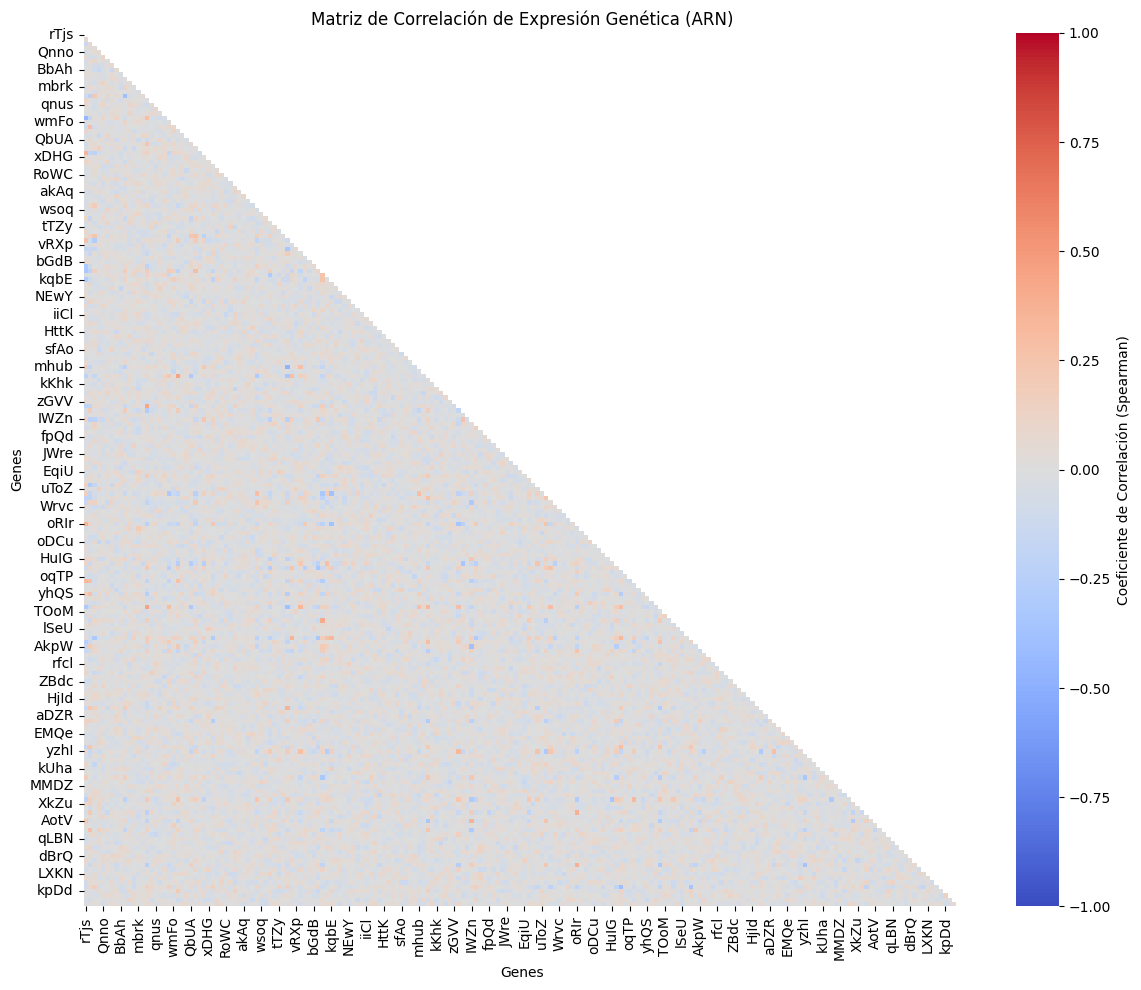

Series([], dtype: float64)


In [70]:
X = df.drop(columns=['target'])

matriz_corr = X.corr(method='spearman')

mask = np.triu(np.ones_like(matriz_corr, dtype=bool))

plt.figure(figsize=(12, 10))
sns.heatmap(
    matriz_corr, 
    mask=mask, 
    cmap='coolwarm', 
    center=0, 
    vmin=-1, 
    vmax=1, 
    cbar_kws={'label': 'Coeficiente de Correlación (Spearman)'}
)
plt.title('Matriz de Correlación de Expresión Genética (ARN)')
plt.xlabel('Genes')
plt.ylabel('Genes')
plt.tight_layout()
plt.show()

coeficiente_umbral = 0.7
correlaciones_apiladas = matriz_corr.mask(mask).stack()
correlaciones_fuertes = correlaciones_apiladas[abs(correlaciones_apiladas) > coeficiente_umbral].sort_values(ascending=False)
print(correlaciones_fuertes) # Qué gen tiene una correlación marcada.

#### Correlación dada la Clase

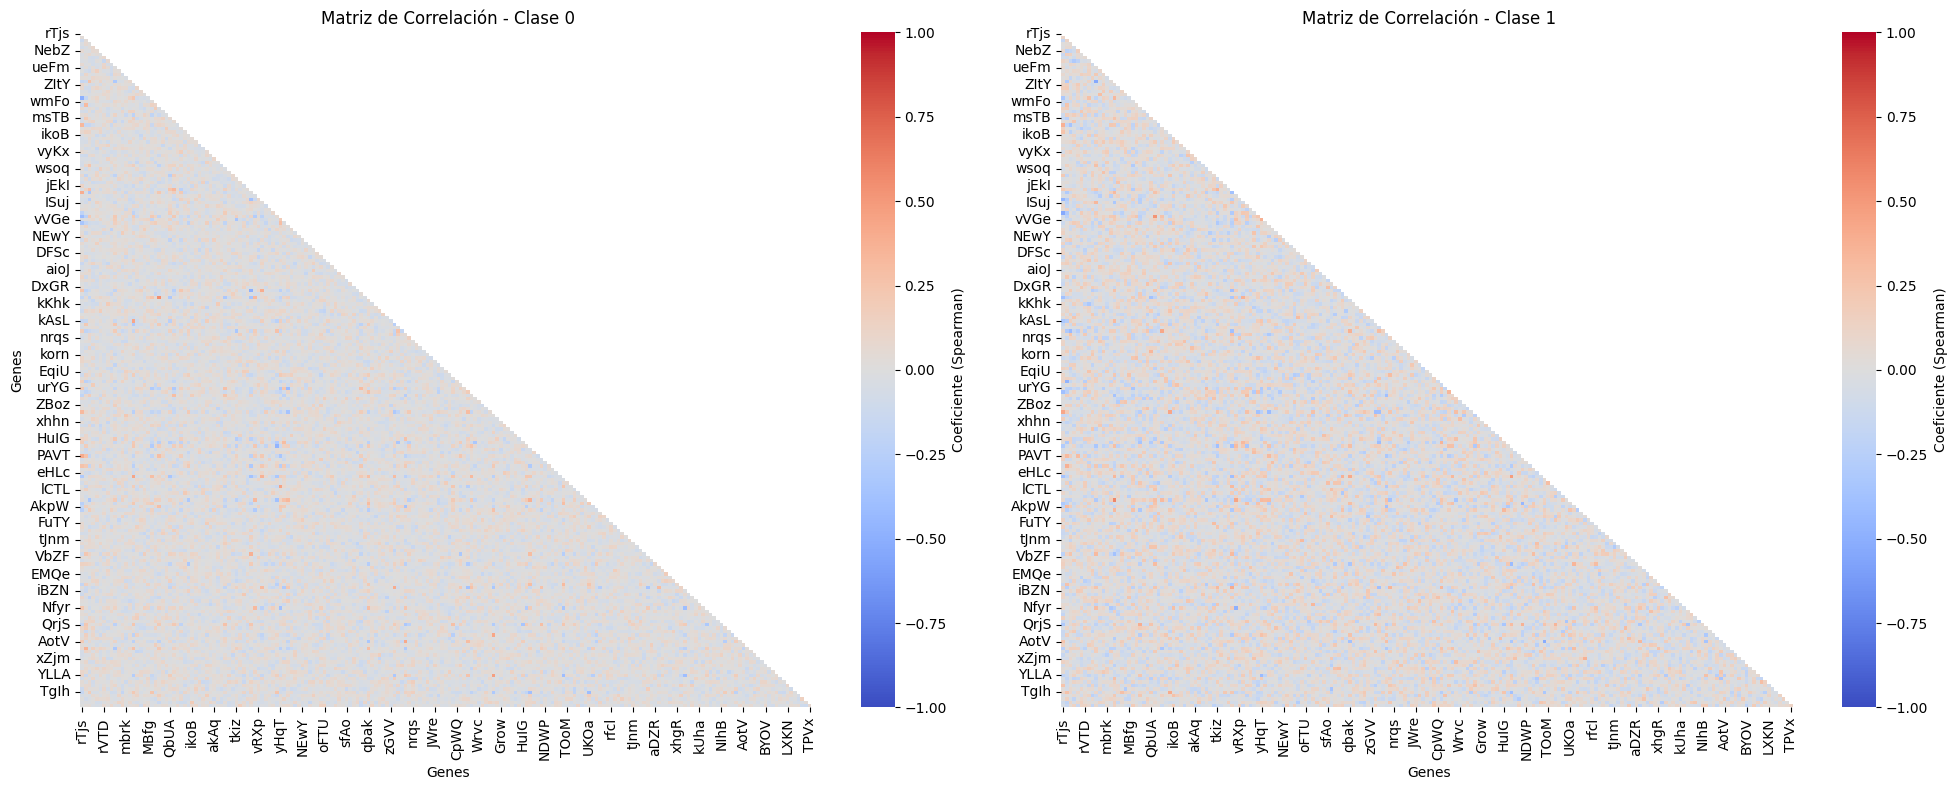

Genes con correlación fuerte en Clase 0:
Series([], dtype: float64)

Genes con correlación fuerte en Clase 1:
Series([], dtype: float64)


In [71]:
X_0 = df[df['target'] == 0].drop(columns=['target'])
X_1 = df[df['target'] == 1].drop(columns=['target'])

corr_0 = X_0.corr(method='spearman')
corr_1 = X_1.corr(method='spearman')

mask = np.triu(np.ones_like(corr_0, dtype=bool))

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

sns.heatmap(
    corr_0, 
    mask=mask, 
    cmap='coolwarm', 
    center=0, 
    vmin=-1, 
    vmax=1, 
    ax=axes[0],
    cbar_kws={'label': 'Coeficiente (Spearman)'}
)
axes[0].set_title('Matriz de Correlación - Clase 0')
axes[0].set_xlabel('Genes')
axes[0].set_ylabel('Genes')

sns.heatmap(
    corr_1, 
    mask=mask, 
    cmap='coolwarm', 
    center=0, 
    vmin=-1, 
    vmax=1, 
    ax=axes[1],
    cbar_kws={'label': 'Coeficiente (Spearman)'}
)
axes[1].set_title('Matriz de Correlación - Clase 1')
axes[1].set_xlabel('Genes')
axes[1].set_ylabel('') 

plt.tight_layout()
plt.show()

coeficiente_umbral = 0.7
print("Genes con correlación fuerte en Clase 0:")
correlaciones_apiladas_0 = corr_0.mask(mask).stack()
correlaciones_fuertes_0 = correlaciones_apiladas_0[abs(correlaciones_apiladas_0) > coeficiente_umbral].sort_values(ascending=False)
print(correlaciones_fuertes_0)

print("\nGenes con correlación fuerte en Clase 1:")
correlaciones_apiladas_1 = corr_1.mask(mask).stack()
correlaciones_fuertes_1 = correlaciones_apiladas_1[abs(correlaciones_apiladas_1) > coeficiente_umbral].sort_values(ascending=False)
print(correlaciones_fuertes_1)

### Análisis de Normalidad en los Atributos dada la Clase

In [72]:
resultados_condicionales = []

for clase in [0, 1]:
    df_clase = df[df['target'] == clase].drop(columns=['target'])
    
    for gen in df_clase.columns:
        data = df_clase[gen].dropna()
        
        _, p_shapiro = shapiro(data)
        es_normal_shapiro = p_shapiro > 0.05
             
        resultados_condicionales.append({
            'Clase': clase,
            'Gen': gen,
            'p_valor_Shapiro': p_shapiro,
            'Normal_Shapiro': es_normal_shapiro,
        })

df_tests_condicional = pd.DataFrame(resultados_condicionales)

display(df_tests_condicional.sort_values(by=['Clase', 'p_valor_Shapiro'], ascending=[True, True]).head(15))

,Clase,Gen,p_valor_Shapiro,Normal_Shapiro
19,0,Jbcl,0.000274,False
23,0,NtjU,0.001213,False
73,0,cvxh,0.002031,False
12,0,mbrk,0.009235,False
28,0,xDHG,0.012950,False
77,0,qHhS,0.021887,False
122,0,GLoy,0.022820,False
130,0,eHLc,0.031694,False
101,0,SZxQ,0.031777,False
65,0,DFSc,0.033604,False


#### Histogramas de Atributos dada la Clase

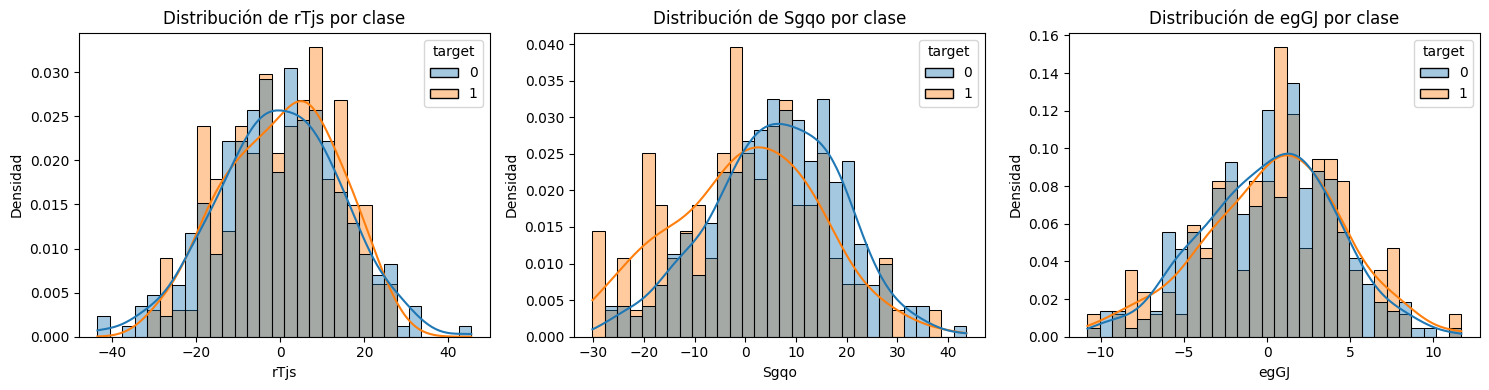

In [73]:
target = 'target'
features = [col for col in df.columns if col != target]
features = features[:3]

n_cols = 3
n_rows = math.ceil(len(features) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.histplot(
        data=df,
        x=feature,
        hue=target,
        kde=True,
        stat="density",
        common_norm=False,
        bins=30,
        alpha=0.4,
        ax=axes[i]
    )
    
    axes[i].set_title(f"Distribución de {feature} por clase")
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("Densidad")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Análisis de Normalidad Multivariable dada la Clase

In [74]:
def tests_multivariables(df, nombre_dataset="Dataset", target_col='target'):
   
    print(f"RESULTADOS PARA: {nombre_dataset}")
    print("-" * 50)
    
    X_clase_0 = df[df[target_col] == 0].drop(columns=[target_col])
    X_clase_1 = df[df[target_col] == 1].drop(columns=[target_col])
    
    mvn_0 = pg.multivariate_normality(X_clase_0)
    mvn_1 = pg.multivariate_normality(X_clase_1)
    
    print("Test de Normalidad Multivariable (Henze-Zirkler):")
    print(f"Clase 0 -> Normal: {mvn_0.normal} | p-valor: {mvn_0.pval}")
    print(f"Clase 1 -> Normal: {mvn_1.normal} | p-valor: {mvn_1.pval}\n")
    
    lista_genes = df.drop(columns=[target_col]).columns.tolist()
    
    try:
        res_box = pg.box_m(df, dvs=lista_genes, group=target_col)
        print("Test de Igualdad de Covarianzas (Box's M):")
        print(f"Matrices iguales: {res_box['equal_cov'].iloc[0]} | p-valor: {res_box['pval'].iloc[0]}")
        display(res_box)
    except Exception as e:
        print("Test de Igualdad de Covarianzas (Box's M):")
        print(f"ERROR MATEMÁTICO: {e}")
        
    print("=" * 60, "\n")

In [75]:
tests_multivariables(df, nombre_dataset="Dataset de Desarrollo", target_col='target')

RESULTADOS PARA: Dataset de Desarrollo
--------------------------------------------------
Test de Normalidad Multivariable (Henze-Zirkler):
Clase 0 -> Normal: False | p-valor: 0.0
Clase 1 -> Normal: False | p-valor: 0.0

Test de Igualdad de Covarianzas (Box's M):
Matrices iguales: False | p-valor: nan


/opt/miniconda3/lib/python3.13/site-packages/pingouin/multivariate.py:372: RuntimeWarning: invalid value encountered in power
  M = ((np.linalg.det(covs) / S_det) ** (v / 2)).prod()


,Chi2,df,pval,equal_cov
box,NaN,20100.0,NaN,False


No tiene sentido realizar este test al tener solo 400 datos para 200 atributos. Para calcular la matriz de covarianza de 200 variables se necesitarían estimar unas 20 mil relaciones cruzadas, por lo cual no hay suficientes datos para calcularla de manera estable.   

Sin embargo, si discriminamos por aquellos atributos que tienen la mayor varianza entre las medias de sus distribuciones dada la clase, entonces el test puede brindarnos información sobre qué esta pasando. Resulta ser que de esta manera una de las distribuciones dada la clase si es una Normal Multivariable.  

In [76]:
medias = df.groupby('target').mean()
separacion = medias.var()
atributos_top = separacion.nlargest(40).index.tolist()

df_medias = df[atributos_top + ['target']].copy()

tests_multivariables(df_medias, nombre_dataset="Dataset de Desarrollo (Top 40 Atributos)", target_col='target')

RESULTADOS PARA: Dataset de Desarrollo (Top 40 Atributos)
--------------------------------------------------
Test de Normalidad Multivariable (Henze-Zirkler):
Clase 0 -> Normal: False | p-valor: 2.964260264799869e-07
Clase 1 -> Normal: True | p-valor: 0.2803911091787315

Test de Igualdad de Covarianzas (Box's M):
Matrices iguales: False | p-valor: 0.0


/opt/miniconda3/lib/python3.13/site-packages/pingouin/multivariate.py:386: RuntimeWarning: divide by zero encountered in log
  u = -2 * (1 - c) * np.log(M)


,Chi2,df,pval,equal_cov
box,inf,820.0,0.0,False


El método inicial solo evaluaba la distancia entre las medias. Para mejorar la selección, es necesario ponderar la importancia de cada atributo penalizando por su varianza. Este enfoque es, en esencia, el Análisis de Varianza (ANOVA).

In [77]:
X = df.drop(columns=['target'])
y = df['target']
k_mejores = 40

selector = SelectKBest(score_func=f_classif, k=k_mejores)
selector.fit(X, y)

atributos_top = X.columns[selector.get_support()].tolist()

df_anova = df[atributos_top + ['target']].copy()

tests_multivariables(df_anova, nombre_dataset="Dataset de Desarrollo (Top 40 Atributos - ANOVA)", target_col='target')

RESULTADOS PARA: Dataset de Desarrollo (Top 40 Atributos - ANOVA)
--------------------------------------------------
Test de Normalidad Multivariable (Henze-Zirkler):
Clase 0 -> Normal: True | p-valor: 0.38680413539578484
Clase 1 -> Normal: True | p-valor: 0.1852469758149603

Test de Igualdad de Covarianzas (Box's M):
Matrices iguales: False | p-valor: 5.256428804252458e-13


,Chi2,df,pval,equal_cov
box,1142.456667,820.0,5.256429e-13,False



### Modelos en Filtrando Atributos

Siguiendo la idea anterior, probamos nuevos modelos variando la cantidad de atributos filtrados.

In [78]:
# Modelos ya había sido definido previamente, ahora agregamos QDA con regularización
modelos["QDA"] = QuadraticDiscriminantAnalysis(reg_param=0.01)

In [79]:
def evaluar_modelos_por_medias(separacion, y, modelos, cv, k_min=1, k_max=49):
    resultados = []

    for k in range(k_min, k_max + 1):
        atributos_top = separacion.nlargest(k).index.tolist()
        X_filtrado = df[atributos_top]

        for nombre_modelo, modelo in modelos.items():
            resultados_nb = cross_validate(
                modelo,
                X_filtrado,
                y,
                cv=cv,
                scoring=['roc_auc', 'accuracy']
            )

            resultados.append({
                'k': k,
                'Modelo': nombre_modelo,
                'AUCROC': resultados_nb['test_roc_auc'].mean(),
                'Accuracy': resultados_nb['test_accuracy'].mean()
            })

    return pd.DataFrame(resultados)

medias = df.groupby('target').mean()
separacion = medias.var()
y = df['target']

df_scores_medias = evaluar_modelos_por_medias(separacion, y, modelos, stratifiedKFold, k_min=1, k_max=50)

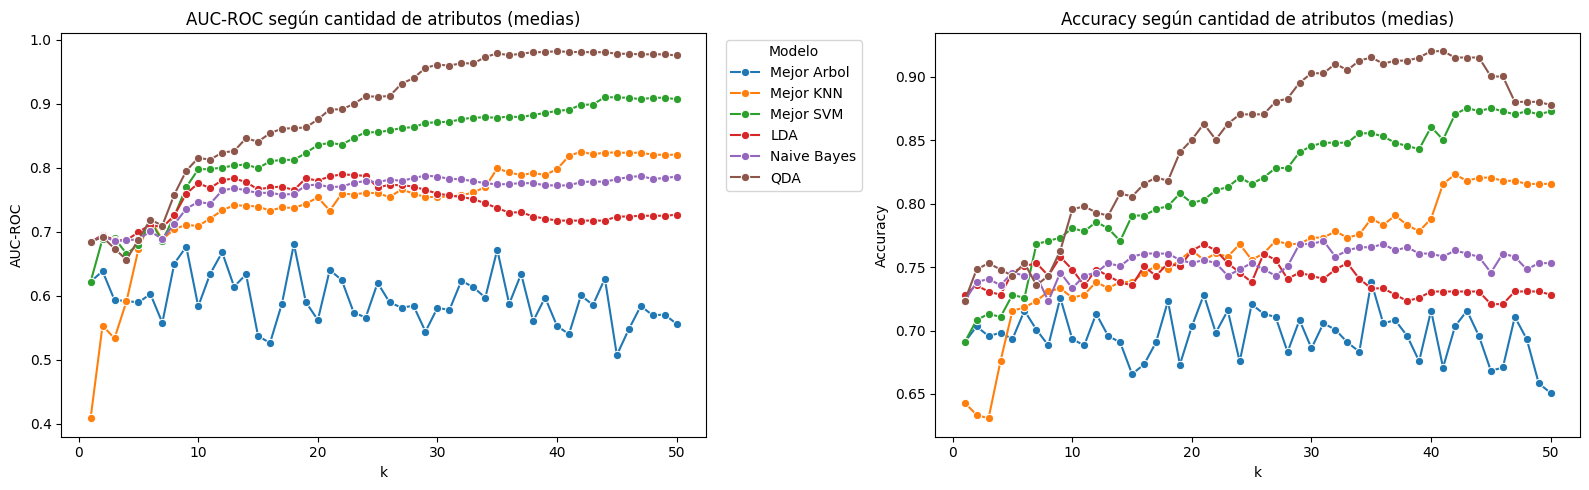

In [80]:
df_plot = df_scores_medias.melt(id_vars=['k', 'Modelo'], value_vars=['AUCROC', 'Accuracy'], var_name='Metrica', value_name='Score')

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharex=True)

sns.lineplot(
    data=df_plot[df_plot['Metrica'] == 'AUCROC'],
    x='k',
    y='Score',
    hue='Modelo',
    marker='o',
    ax=axes[0]
 )
axes[0].set_title('AUC-ROC según cantidad de atributos (medias)')
axes[0].set_xlabel('k')
axes[0].set_ylabel('AUC-ROC')

sns.lineplot(
    data=df_plot[df_plot['Metrica'] == 'Accuracy'],
    x='k',
    y='Score',
    hue='Modelo',
    marker='o',
    ax=axes[1]
 )
axes[1].set_title('Accuracy según cantidad de atributos (medias)')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Accuracy')

handles, labels = axes[1].get_legend_handles_labels()
axes[1].legend_.remove()
axes[0].legend(handles, labels, title='Modelo', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [81]:
mejor_fila_medias = df_scores_medias.loc[df_scores_medias['AUCROC'].idxmax()]
mejor_k_medias = int(mejor_fila_medias['k'])

atributos_seleccionados_medias = separacion.nlargest(mejor_k_medias).index.tolist()
X_train_medias = df[atributos_seleccionados_medias]
X_control_medias = df_control[atributos_seleccionados_medias]

df_mejor_modelo_medias = evaluar_modelos_en_control(
    modelos,
    X_train_medias,
    y,
    X_control_medias,
    df_control['target']
)

df_mejor_modelo_medias

,Modelo,Accuracy (control),Accuracy Mayoritaria (control),Accuracy Minoritaria (control),AUC-PRC (control),AUC-ROC (control)
0,Mejor Arbol,0.707071,97.18,3.57,0.304487,0.535714
1,Mejor KNN,0.767677,90.14,42.86,0.588967,0.793511
2,Mejor SVM,0.828283,88.73,67.86,0.821352,0.907948
3,LDA,0.686869,88.73,17.86,0.472036,0.728370
4,Naive Bayes,0.737374,80.28,57.14,0.646839,0.782696
5,QDA,0.939394,100.00,78.57,0.965190,0.982897


In [82]:
def evaluar_modelos_por_k(X, y, modelos, cv, k_min=1, k_max=50):
    resultados = []

    for k in range(k_min, k_max + 1):
        selector = SelectKBest(score_func=f_classif, k=k)
        selector.fit(X, y)

        atributos_top = X.columns[selector.get_support()].tolist()
        X_filtrado = X[atributos_top]

        for nombre_modelo, modelo in modelos.items():
            resultados_nb = cross_validate(
                modelo,
                X_filtrado,
                y,
                cv=cv,
                scoring=['roc_auc', 'accuracy']
            )

            resultados.append({
                'k': k,
                'Modelo': nombre_modelo,
                'AUCROC': resultados_nb['test_roc_auc'].mean(),
                'Accuracy': resultados_nb['test_accuracy'].mean()
            })

    return pd.DataFrame(resultados)

X = df.drop(columns=['target'])
y = df['target']

df_scores = evaluar_modelos_por_k(X, y, modelos, stratifiedKFold, k_min=1, k_max=50)

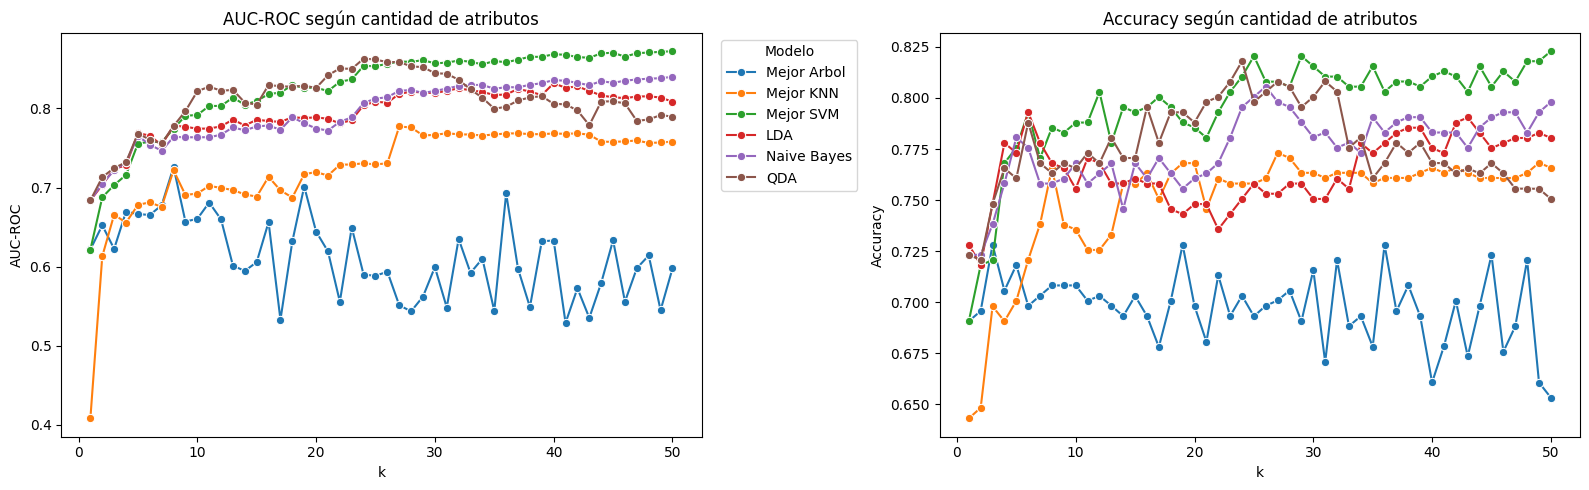

In [83]:
df_plot = df_scores.melt(id_vars=['k', 'Modelo'], value_vars=['AUCROC', 'Accuracy'], var_name='Metrica', value_name='Score')

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharex=True)

sns.lineplot(
    data=df_plot[df_plot['Metrica'] == 'AUCROC'],
    x='k',
    y='Score',
    hue='Modelo',
    marker='o',
    ax=axes[0]
 )
axes[0].set_title('AUC-ROC según cantidad de atributos')
axes[0].set_xlabel('k')
axes[0].set_ylabel('AUC-ROC')

sns.lineplot(
    data=df_plot[df_plot['Metrica'] == 'Accuracy'],
    x='k',
    y='Score',
    hue='Modelo',
    marker='o',
    ax=axes[1]
 )
axes[1].set_title('Accuracy según cantidad de atributos')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Accuracy')

handles, labels = axes[1].get_legend_handles_labels()
axes[1].legend_.remove()
axes[0].legend(handles, labels, title='Modelo', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [84]:
mejor_fila_anova = df_scores.loc[df_scores['AUCROC'].idxmax()]
mejor_k_anova = int(mejor_fila_anova['k'])

selector = SelectKBest(score_func=f_classif, k=mejor_k_anova)
selector.fit(X, y)
atributos_seleccionados_anova = X.columns[selector.get_support()].tolist()

X_train_anova = df[atributos_seleccionados_anova]
X_control_anova = df_control[atributos_seleccionados_anova]

df_mejor_modelo_anova = evaluar_modelos_en_control(
    modelos,
    X_train_anova,
    y,
    X_control_anova,
    df_control['target']
)

df_mejor_modelo_anova

,Modelo,Accuracy (control),Accuracy Mayoritaria (control),Accuracy Minoritaria (control),AUC-PRC (control),AUC-ROC (control)
0,Mejor Arbol,0.727273,97.18,10.71,0.319430,0.530181
1,Mejor KNN,0.707071,83.10,39.29,0.435047,0.663984
2,Mejor SVM,0.797980,90.14,53.57,0.734834,0.850101
3,LDA,0.717172,87.32,32.14,0.549982,0.704225
4,Naive Bayes,0.717172,84.51,39.29,0.651874,0.796278
5,QDA,0.838384,100.00,42.86,0.857898,0.906439
